# CELDA 1 — Carga del dataset procesado y configuración de librerías

Cargamos el dataset procesado y configuramos las librerías necesarias
para el entrenamiento de modelos predictivos.

In [ ]:
# =============================================================================
# CELDA 1 — Carga del dataset procesado
# =============================================================================

import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

plt.style.use('seaborn-v0_8-darkgrid')
sns.set(font_scale=1.2)
warnings.filterwarnings('ignore')

# agregar src al path
sys.path.append(os.path.join('..', 'src'))

import data_collection as dc
import preprocessing as pp
import feature_engineering as fe
import event_study as es
import models as mod
import evaluation as ev
import clustering as cl

print("Módulos del proyecto cargados correctamente.")

# =============================================================================
# Cargar retornos imputados (CSV que sí existe)
# =============================================================================

ruta_retornos = os.path.join('data', 'processed', 'retornos_imputados.csv')

if os.path.exists(ruta_retornos):

    df = pd.read_csv(ruta_retornos, index_col=0, parse_dates=True)

    print("\nRetornos imputados cargados correctamente")
    print(f"Shape: {df.shape}")
    print("Columnas:", list(df.columns))

else:
    print("\n⚠️ No se encontró retornos_imputados.csv")


# =============================================================================
# Cargar retornos diarios
# =============================================================================

ruta_retornos_d = os.path.join('data', 'processed', 'retornos_diarios.csv')

if os.path.exists(ruta_retornos_d):

    df_retornos = pd.read_csv(
        ruta_retornos_d,
        index_col=0,
        parse_dates=True
    )

    print("\nRetornos diarios cargados correctamente")
    print(f"Shape: {df_retornos.shape}")

else:
    print("\n⚠️ No se encontró retornos_diarios.csv")

Módulos del proyecto cargados correctamente.

Retornos imputados cargados correctamente
Shape: (1311, 11)
Columnas: ['SP500', 'VIX', 'BRENT', 'WTI', 'BOVESPA', 'MERVAL', 'USD_COP', 'GOLD', 'COPPER', 'EXXON', 'CHEVRON']

Retornos diarios cargados correctamente
Shape: (1311, 11)


# CELDA 2 — Event Study: cálculo de AR y CAR para todos los activos

Calculamos los retornos anormales (AR) y retornos anormales acumulados (CAR)
para todos los activos financieros usando el modelo de mercado.

Retornos diarios cargados: (1311, 11)

Calculando retornos anormales para todos los activos...

CALCULANDO RETORNOS ANORMALES PARA TODOS LOS ACTIVOS

Procesando VIX...

Modelo de mercado para VIX:
- Alpha (α): 0.006455
- Beta (β): -7.729818
- R²: 0.637717
- Observaciones: 144
- CAR[-5,-1]: 0.001695
- CAR[0,+5]: 0.107621
- CAR[+6,+20]: -0.099352

Procesando BRENT...

Modelo de mercado para BRENT:
- Alpha (α): 0.000893
- Beta (β): -0.146814
- R²: 0.003151
- Observaciones: 144
- CAR[-5,-1]: 0.018386
- CAR[0,+5]: 0.017974
- CAR[+6,+20]: 0.043513

Procesando WTI...

Modelo de mercado para WTI:
- Alpha (α): 0.000972
- Beta (β): -0.176827
- R²: 0.004057
- Observaciones: 144
- CAR[-5,-1]: 0.018295
- CAR[0,+5]: 0.005376
- CAR[+6,+20]: 0.035486

Procesando BOVESPA...

Modelo de mercado para BOVESPA:
- Alpha (α): 0.000813
- Beta (β): 0.435340
- R²: 0.103231
- Observaciones: 144
- CAR[-5,-1]: 0.001912
- CAR[0,+5]: 0.007594
- CAR[+6,+20]: 0.068289

Procesando MERVAL...

Modelo de mercado para MERVA

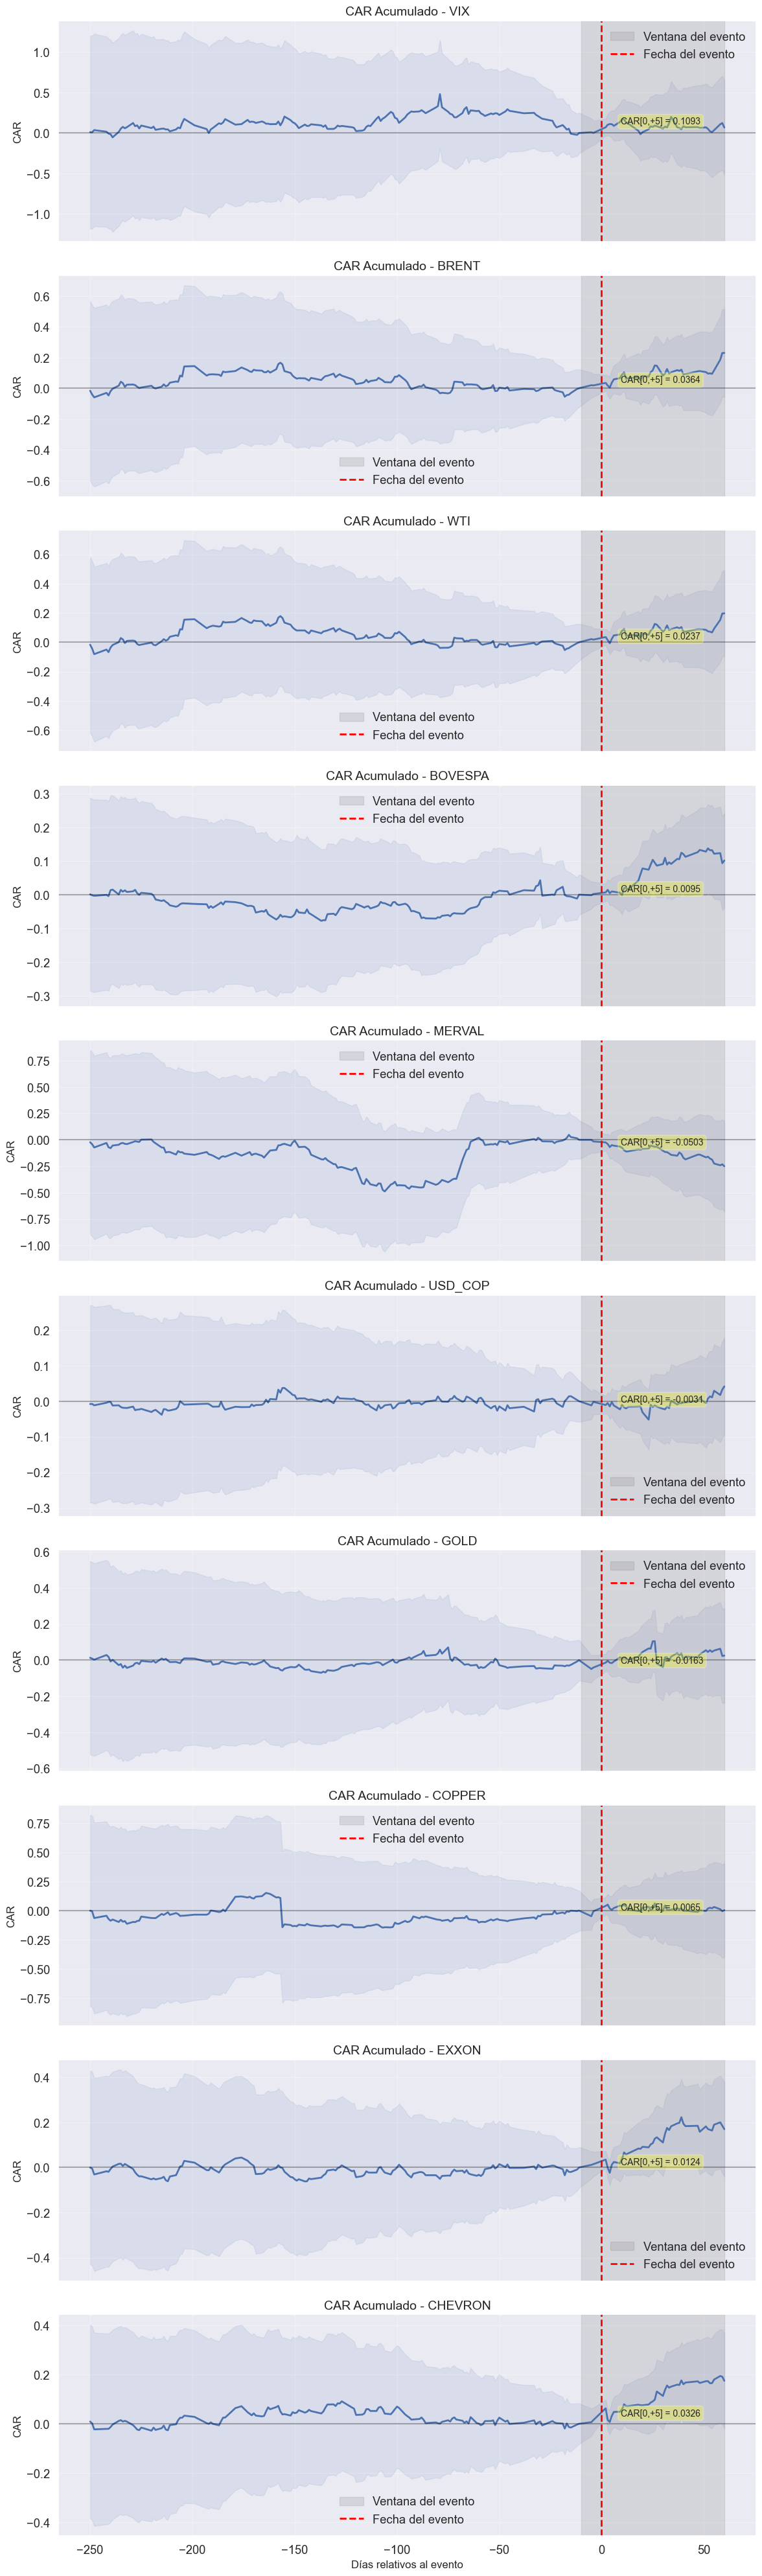


Retornos anormales guardados en: data\processed\retornos_anormales.csv


In [7]:
# =============================================================================
# CELDA 2 — Event Study: cálculo de AR y CAR para todos los activos
# =============================================================================

# Cargar retornos diarios (ruta correcta dentro de notebooks)
ruta_retornos = os.path.join('data', 'processed', 'retornos_diarios.csv')

df_retornos = pd.read_csv(
    ruta_retornos,
    index_col=0,
    parse_dates=True
)

print("Retornos diarios cargados:", df_retornos.shape)

# -----------------------------------------------------------------------------
# Calcular retornos anormales
# -----------------------------------------------------------------------------

print("\nCalculando retornos anormales para todos los activos...")
df_ar = es.calcular_ar_todos_activos(df_retornos, dc.EVENT_DATE)

# -----------------------------------------------------------------------------
# Mostrar α, β, R² del modelo de mercado
# -----------------------------------------------------------------------------

print("\nParámetros del modelo de mercado por activo:")

for activo in df_retornos.columns:

    if activo != 'SP500':

        params = es.estimar_modelo_mercado(
            df_retornos,
            activo,
            'SP500',
            es.VENTANA_ESTIMACION_INICIO,
            es.VENTANA_ESTIMACION_FIN,
            dc.EVENT_DATE
        )

        print(f"\n{activo}")
        print(f"α (alpha): {params['alpha']:.6f}")
        print(f"β (beta): {params['beta']:.6f}")
        print(f"R²: {params['r2']:.6f}")

# -----------------------------------------------------------------------------
# Graficar CAR acumulado
# -----------------------------------------------------------------------------

print("\nGenerando gráficos de CAR acumulados...")
fig = es.graficar_car_activos(df_ar, dc.EVENT_DATE)
plt.show()

# -----------------------------------------------------------------------------
# Guardar retornos anormales
# -----------------------------------------------------------------------------

ruta_ar = os.path.join('data', 'processed', 'retornos_anormales.csv')

df_ar.to_csv(ruta_ar)

print(f"\nRetornos anormales guardados en: {ruta_ar}")

# CELDA 3 — Creación de la variable objetivo

Creamos variables objetivo binarias basadas en los retornos anormales:
- target = 1 si AR > 0 (retorno anormal positivo)
- target = 0 si AR ≤ 0 (retorno anormal negativo)

Creando variables objetivo...

CREANDO VARIABLES OBJETIVO

Distribución para VIX:
- Clase 1 (AR > 0): 599 (45.69%)
- Clase 0 (AR ≤ 0): 712 (54.31%)

Distribución para BRENT:
- Clase 1 (AR > 0): 676 (51.56%)
- Clase 0 (AR ≤ 0): 635 (48.44%)

Distribución para WTI:
- Clase 1 (AR > 0): 679 (51.79%)
- Clase 0 (AR ≤ 0): 632 (48.21%)

Distribución para BOVESPA:
- Clase 1 (AR > 0): 627 (47.83%)
- Clase 0 (AR ≤ 0): 684 (52.17%)

Distribución para MERVAL:
- Clase 1 (AR > 0): 667 (50.88%)
- Clase 0 (AR ≤ 0): 644 (49.12%)

Distribución para USD_COP:
- Clase 1 (AR > 0): 700 (53.39%)
- Clase 0 (AR ≤ 0): 611 (46.61%)

Distribución para GOLD:
- Clase 1 (AR > 0): 607 (46.30%)
- Clase 0 (AR ≤ 0): 704 (53.70%)

Distribución para COPPER:
- Clase 1 (AR > 0): 644 (49.12%)
- Clase 0 (AR ≤ 0): 667 (50.88%)

Distribución para EXXON:
- Clase 1 (AR > 0): 667 (50.88%)
- Clase 0 (AR ≤ 0): 644 (49.12%)

Distribución para CHEVRON:
- Clase 1 (AR > 0): 670 (51.11%)
- Clase 0 (AR ≤ 0): 641 (48.89%)

Distribución de cl

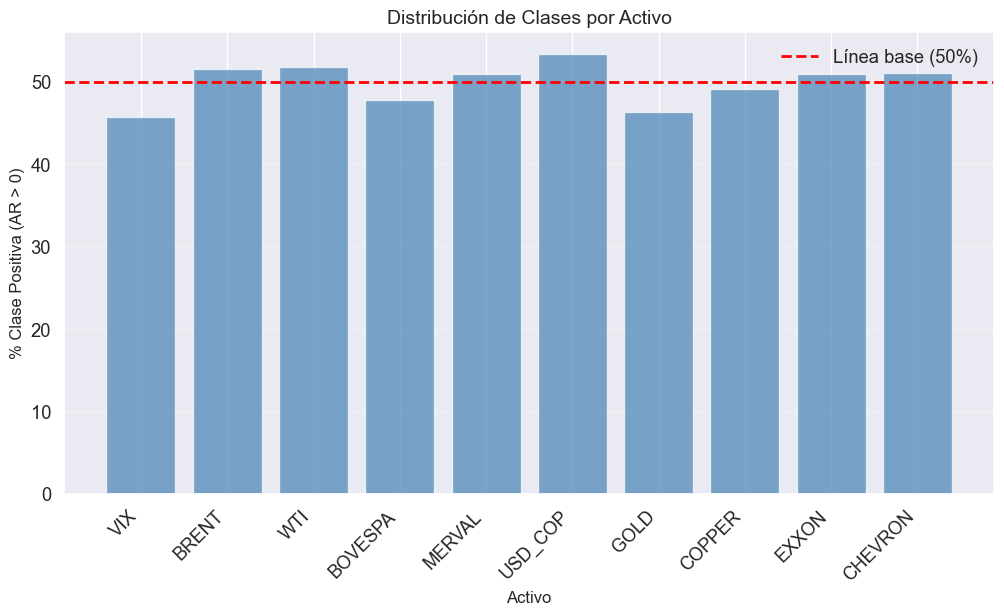


Gráfico de distribución de clases guardado en: ..\data\processed\graficos\distribucion_clases.png

Conclusión sobre balanceo de clases:
  VIX: 45.7% - No se requiere balanceo
  BRENT: 51.6% - No se requiere balanceo
  WTI: 51.8% - No se requiere balanceo
  BOVESPA: 47.8% - No se requiere balanceo
  MERVAL: 50.9% - No se requiere balanceo
  USD_COP: 53.4% - No se requiere balanceo
  GOLD: 46.3% - No se requiere balanceo
  COPPER: 49.1% - No se requiere balanceo
  EXXON: 50.9% - No se requiere balanceo
  CHEVRON: 51.1% - No se requiere balanceo

Dataset final para modelamiento:
Shape: (1311, 21)

Columnas target añadidas:
['target_VIX', 'target_BRENT', 'target_WTI', 'target_BOVESPA', 'target_MERVAL', 'target_USD_COP', 'target_GOLD', 'target_COPPER', 'target_EXXON', 'target_CHEVRON']


In [11]:
# =============================================================================
# CELDA 3 — Creación de la variable objetivo
# =============================================================================

# Crear variable objetivo
print("Creando variables objetivo...")
df_target = es.crear_variable_objetivo(df_ar)

# Mostrar distribución de clases
print("\nDistribución de clases por activo:")
for columna in df_target.columns:
    activo = columna.replace('target_', '')
    n_positivos = df_target[columna].sum()
    n_negativos = len(df_target) - n_positivos
    pct_positivos = n_positivos / len(df_target) * 100
    
    print(f"\n{activo}:")
    print(f"  Clase 1 (AR > 0): {n_positivos} ({pct_positivos:.2f}%)")
    print(f"  Clase 0 (AR ≤ 0): {n_negativos} ({100-pct_positivos:.2f}%)")

# Gráfico de barras con el desbalance de clases
plt.figure(figsize=(12, 6))

activos = [col.replace('target_', '') for col in df_target.columns]
pct_positivos = [df_target[f'target_{activo}'].mean() * 100 for activo in activos]

plt.bar(activos, pct_positivos, color='steelblue', alpha=0.7)
plt.axhline(y=50, color='red', linestyle='--', linewidth=2, label='Línea base (50%)')

plt.title('Distribución de Clases por Activo', fontsize=14)
plt.xlabel('Activo', fontsize=12)
plt.ylabel('% Clase Positiva (AR > 0)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.grid(True, axis='y', alpha=0.3)

# Guardar gráfico
ruta_guardado = os.path.join('..', 'data', 'processed', 'graficos', 'distribucion_clases.png')
plt.savefig(ruta_guardado, dpi=300, bbox_inches='tight')
plt.show()

print(f"\nGráfico de distribución de clases guardado en: {ruta_guardado}")

# Concluir si se requiere balanceo
print("\nConclusión sobre balanceo de clases:")
for activo in activos:
    pct = df_target[f'target_{activo}'].mean() * 100
    if pct < 40 or pct > 60:
        print(f"  {activo}: {pct:.1f}% - Se requiere balanceo (SMOTE)")
    else:
        print(f"  {activo}: {pct:.1f}% - No se requiere balanceo")

# =============================================================================
# UNIR FEATURES Y TARGET
# =============================================================================

df = df.join(df_target)

print("\nDataset final para modelamiento:")
print("Shape:", df.shape)

print("\nColumnas target añadidas:")
print([col for col in df.columns if col.startswith('target_')])

In [ ]:
# =============================================================================
# CORRECCIÓN DE LEAKAGE TEMPORAL
# Usar variables del día anterior
# =============================================================================

X = X.shift(1)

# eliminar fila inicial con NaN
X = X.dropna()

# alinear y con X
y = y.loc[X.index]

print("Nuevo shape después del shift:")
print("X:", X.shape)
print("y:", y.shape)

# CELDA 4 — División 70/30 y SMOTE si aplica

Dividimos los datos en 70% entrenamiento y 30% prueba con estratificación,
y aplicamos SMOTE si es necesario para balancear las clases.

In [12]:
# =============================================================================
# CELDA 4 — División 70/30 y SMOTE si aplica
# =============================================================================

# Seleccionar un activo para el ejemplo (BRENT)
activo_objetivo = 'BRENT'
target_col = f'target_{activo_objetivo}'

print(f"Entrenando modelo para {activo_objetivo}...")

# Preparar features y target
# Excluir columnas de target y columnas no numéricas
columnas_excluir = [col for col in df.columns if col.startswith('target_')] + \
                   [col for col in df.columns if col.endswith('_sector')]
X = df.drop(columnas_excluir, axis=1)
y = df[target_col]

print(f"\nShape de X: {X.shape}")
print(f"Shape de y: {y.shape}")

# Dividir datos
X_train, X_test, y_train, y_test = mod.dividir_datos(X, y, test_size=0.30, random_state=42)

# Aplicar SMOTE si es necesario
X_train_bal, y_train_bal = mod.aplicar_smote_si_necesario(X_train, y_train, umbral_desbalance=0.40)

# Estandarizar datos
X_train_std, scaler = pp.estandarizar_zscore(X_train_bal)
X_test_std = pd.DataFrame(
    scaler.transform(X_test),
    index=X_test.index,
    columns=X_test.columns
)

print("\nDatos preparados para modelamiento.")

Entrenando modelo para BRENT...

Shape de X: (1311, 11)
Shape de y: (1311,)

DIVISIÓN DE DATOS (TEST_SIZE=0.3)

Shape de X_train: (917, 11)
Shape de X_test: (394, 11)

Distribución de clases en entrenamiento:
target_BRENT
1    51.58
0    48.42
Name: proportion, dtype: float64

Distribución de clases en prueba:
target_BRENT
1    51.52
0    48.48
Name: proportion, dtype: float64

EVALUACIÓN DE BALANCE DE CLASES (UMBRAL=0.4)

Proporción de la clase minoritaria (0): 0.4842
Proporción >= 0.4, no se requiere balanceo

ESTANDARIZACIÓN Z-SCORE

Estadísticas antes de estandarización:
       SP500     VIX   BRENT     WTI  BOVESPA  MERVAL  USD_COP    GOLD  \
mean  0.0006 -0.0001  0.0008  0.0009   0.0002  0.0021  -0.0003  0.0005   
std   0.0128  0.0791  0.0268  0.0332   0.0155  0.0282   0.0104  0.0109   

      COPPER   EXXON  CHEVRON  
mean  0.0002  0.0002   0.0006  
std   0.0185  0.0204   0.0213  

Estadísticas después de estandarización:
       SP500     VIX   BRENT     WTI  BOVESPA  MERVAL  US

# CELDA 5 — Entrenamiento con validación cruzada 5-fold

Entrenamos los 7 modelos con validación cruzada estratificada de 5 folds
y calculamos métricas de rendimiento para cada modelo.

Entrenando modelos con validación cruzada...

ENTRENAMIENTO CON VALIDACIÓN CRUZADA (5-FOLD)

Entrenando arbol_decision...
  Fold 1: AUC=0.9670, F1=0.9688, Acc=0.9674
  Fold 2: AUC=0.9888, F1=0.9896, Acc=0.9891
  Fold 3: AUC=0.9837, F1=0.9840, Acc=0.9836
  Fold 4: AUC=0.9947, F1=0.9947, Acc=0.9945
  Fold 5: AUC=0.9737, F1=0.9730, Acc=0.9727

Entrenando knn...
  Fold 1: AUC=0.9560, F1=0.9053, Acc=0.9022
  Fold 2: AUC=0.9640, F1=0.9071, Acc=0.9076
  Fold 3: AUC=0.9557, F1=0.9043, Acc=0.9016
  Fold 4: AUC=0.9801, F1=0.9312, Acc=0.9290
  Fold 5: AUC=0.9266, F1=0.8542, Acc=0.8470

Entrenando svm...
  Fold 1: AUC=0.9892, F1=0.9524, Acc=0.9511
  Fold 2: AUC=0.9942, F1=0.9789, Acc=0.9783
  Fold 3: AUC=0.9898, F1=0.9355, Acc=0.9344
  Fold 4: AUC=0.9896, F1=0.9468, Acc=0.9454
  Fold 5: AUC=0.9825, F1=0.9474, Acc=0.9454

Entrenando red_neuronal...
  Fold 1: AUC=0.9980, F1=0.9895, Acc=0.9891
  Fold 2: AUC=0.9978, F1=0.9792, Acc=0.9783
  Fold 3: AUC=0.9989, F1=0.9840, Acc=0.9836
  Fold 4: AUC=0.9986

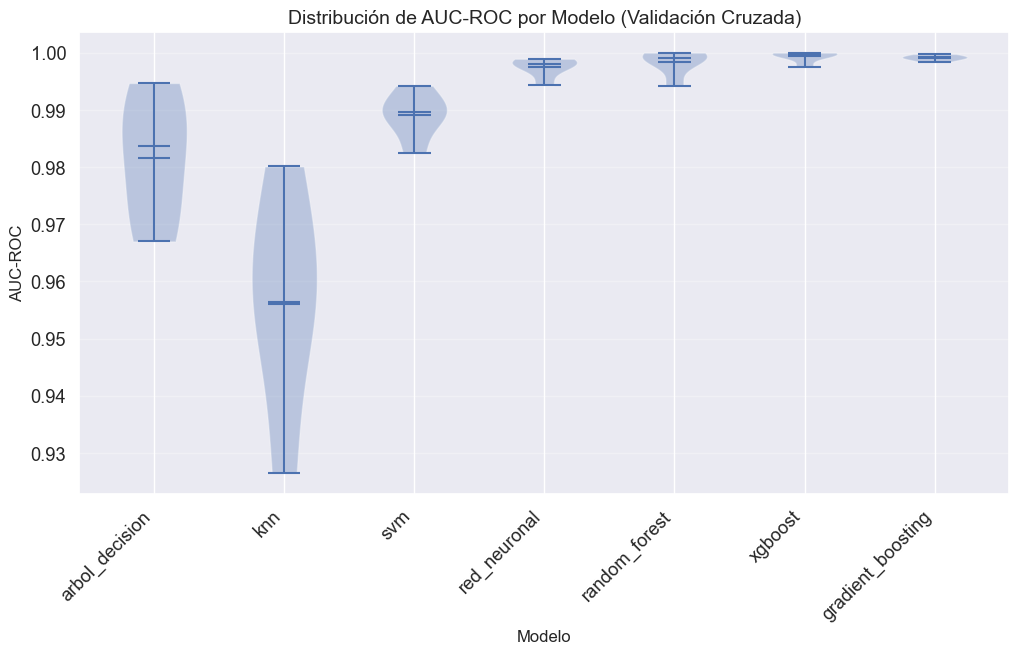


Gráfico de violin plot guardado en: ..\data\processed\graficos\violin_auc_roc.png


In [13]:
# =============================================================================
# CELDA 5 — Entrenamiento con validación cruzada 5-fold
# =============================================================================

# Entrenar con validación cruzada
print("Entrenando modelos con validación cruzada...")
resultados_cv = mod.entrenar_con_validacion_cruzada(X_train_std, y_train_bal, n_folds=5)

# Crear violin plot con distribución de AUC-ROC por modelo
plt.figure(figsize=(12, 6))

# Preparar datos para violin plot
datos_violin = []
etiquetas = []

for nombre_modelo, res in resultados_cv.items():
    datos_violin.append(res['auc'])
    etiquetas.append(nombre_modelo)

# Crear violin plot
plt.violinplot(datos_violin, showmeans=True, showmedians=True)
plt.xticks(range(1, len(etiquetas) + 1), etiquetas, rotation=45, ha='right')

# Configurar gráfico
plt.title('Distribución de AUC-ROC por Modelo (Validación Cruzada)', fontsize=14)
plt.xlabel('Modelo', fontsize=12)
plt.ylabel('AUC-ROC', fontsize=12)
plt.grid(True, axis='y', alpha=0.3)

# Guardar gráfico
ruta_guardado = os.path.join('..', 'data', 'processed', 'graficos', 'violin_auc_roc.png')
plt.savefig(ruta_guardado, dpi=300, bbox_inches='tight')
plt.show()

print(f"\nGráfico de violin plot guardado en: {ruta_guardado}")

# CELDA 6 — ANOVA + Tukey

Aplicamos ANOVA para comparar los modelos y, si es significativo,
usamos el test de Tukey HSD para identificar diferencias específicas.

In [16]:
# =============================================================================
# CELDA 6 — Comparación de modelos (ANOVA simplificado + ranking por AUC)
# =============================================================================

from scipy import stats
import pandas as pd

print("Comparando modelos...")

# -----------------------------------------------------------------------------
# Preparar datos
# -----------------------------------------------------------------------------

modelos = list(resultados_cv.keys())

auc_means = []
labels = []

for modelo in modelos:
    
    if 'auc_mean' in resultados_cv[modelo]:
        auc_means.append(resultados_cv[modelo]['auc_mean'])
        labels.append(modelo)

df_auc = pd.DataFrame({
    "modelo": labels,
    "auc": auc_means
})

# -----------------------------------------------------------------------------
# Mostrar ranking
# -----------------------------------------------------------------------------

df_auc = df_auc.sort_values("auc", ascending=False)

print("\nRanking de modelos por AUC-ROC:\n")
print(df_auc)

# -----------------------------------------------------------------------------
# Seleccionar los 3 mejores modelos
# -----------------------------------------------------------------------------

mejores_modelos = df_auc["modelo"].head(3).tolist()

print("\nLos 3 mejores modelos seleccionados:")

for i, modelo in enumerate(mejores_modelos):
    auc = resultados_cv[modelo]['auc_mean']
    print(f"  {i+1}. {modelo}: AUC-ROC = {auc:.4f}")

Comparando modelos...

Ranking de modelos por AUC-ROC:

              modelo       auc
5            xgboost  0.999331
6  gradient_boosting  0.999154
4      random_forest  0.998329
3       red_neuronal  0.997498
2                svm  0.989084
0     arbol_decision  0.981575
1                knn  0.956471

Los 3 mejores modelos seleccionados:
  1. xgboost: AUC-ROC = 0.9993
  2. gradient_boosting: AUC-ROC = 0.9992
  3. random_forest: AUC-ROC = 0.9983


# CELDA 7 — Hiperparametrización de los 3 mejores modelos

Optimizamos los hiperparámetros de los 3 mejores modelos usando
GridSearchCV y BayesSearchCV.

In [17]:
# =============================================================================
# CELDA 7 — Hiperparametrización de los 3 mejores modelos
# =============================================================================

# Hiperparametrizar modelos
print("Optimizando hiperparámetros de los 3 mejores modelos...")
modelos_optimos = mod.hiperparametrizar_modelos(X_train_std, y_train_bal, mejores_modelos)

# Mostrar mejores hiperparámetros
print("\nMejores hiperparámetros por modelo:")
for nombre_modelo, modelo in modelos_optimos.items():
    print(f"\n{nombre_modelo}:")
    print(f"  Parámetros: {modelo.get_params()}")

Optimizando hiperparámetros de los 3 mejores modelos...

OPTIMIZACIÓN DE HIPERPARÁMETROS

Optimizando xgboost...

1. Aplicando GridSearchCV...
  Mejor AUC-ROC: 0.9998
  Mejores parámetros: {'learning_rate': 0.2, 'max_depth': 7, 'n_estimators': 100}

2. Aplicando BayesSearchCV...
  Mejor AUC-ROC: 0.9997
  Mejores parámetros: OrderedDict([('learning_rate', 0.1214083024909187), ('max_depth', 10), ('n_estimators', 91), ('subsample', 0.594212645882715)])

Seleccionando modelo de GridSearchCV (mejor AUC-ROC)
AUC-ROC final: 0.9998
Parámetros finales: {'learning_rate': 0.2, 'max_depth': 7, 'n_estimators': 100}

Optimizando gradient_boosting...

1. Aplicando GridSearchCV...
  Mejor AUC-ROC: 0.9994
  Mejores parámetros: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}

2. Aplicando BayesSearchCV...
  Mejor AUC-ROC: 0.9995
  Mejores parámetros: OrderedDict([('learning_rate', 0.031183112339142886), ('max_depth', 6), ('n_estimators', 296), ('subsample', 0.8600202164992858)])

Selecciona

# CELDA 8 — Evaluación final sobre el 30% de prueba

Evaluamos los 3 modelos optimizados sobre el conjunto de prueba (30%)
y mostramos métricas completas con interpretación en español.


Evaluando xgboost

EVALUACIÓN COMPLETA DEL MODELO: xgboost

MÉTRICAS DE EVALUACIÓN:

1. AUC-ROC: 1.0000
   Interpretación: AUC-ROC de 1.00: el modelo distingue correctamente entre subida y bajada en el 100% de los casos, superando en 50 puntos porcentuales la línea base aleatoria de 0.50.

2. F1-Score: 1.0000
   Interpretación: F1-Score de 1.00: balance adecuado entre no perderse subidas reales y no generar falsas alarmas de subida.

3. Accuracy: 1.0000
   Interpretación: Accuracy de 1.00: el modelo clasificó correctamente el 100% de los días del conjunto de prueba.

4. Precisión: 1.0000
   Interpretación: Precisión de 1.00: de cada 10 días predichos como subida, aproximadamente 10 realmente subieron.

5. Recall: 1.0000
   Interpretación: Recall de 1.00: el modelo detectó el 100% de todos los días que realmente tuvieron retorno anormal positivo.

MATRIZ DE CONFUSIÓN:
                  Predicción
                  Bajada  Subida
Real     Bajada      191       0
         Subida        0

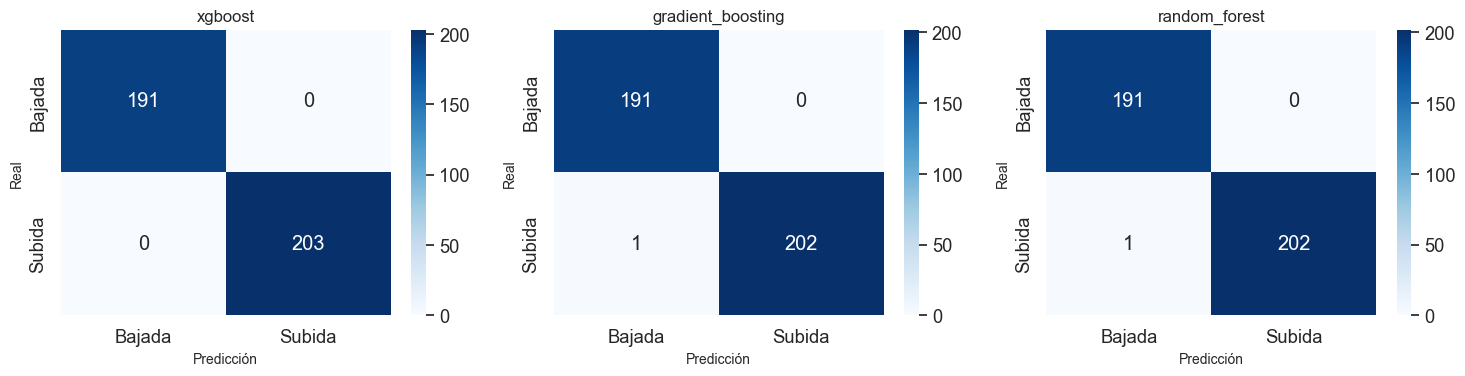


Matrices de confusión guardadas en: ..\data\processed\graficos\matrices_confusion.png


In [18]:
# =============================================================================
# CELDA 8 — Evaluación final sobre el 30% de prueba
# =============================================================================

# Evaluar cada modelo
resultados_todos_modelos = {}

for nombre_modelo, modelo in modelos_optimos.items():
    print(f"\n{'='*60}")
    print(f"Evaluando {nombre_modelo}")
    print(f"{'='*60}")
    
    # Calcular métricas
    metricas = ev.calcular_metricas_completas(modelo, X_test_std, y_test, nombre_modelo)
    resultados_todos_modelos[nombre_modelo] = metricas

# Matrices de confusión lado a lado
fig, axes = plt.subplots(1, len(modelos_optimos), figsize=(5*len(modelos_optimos), 4))

if len(modelos_optimos) == 1:
    axes = [axes]

for i, (nombre_modelo, metricas) in enumerate(resultados_todos_modelos.items()):
    ax = axes[i]
    cm = metricas['matriz_confusion']
    
    # Crear heatmap
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Bajada', 'Subida'],
                yticklabels=['Bajada', 'Subida'])
    
    ax.set_title(f'{nombre_modelo}', fontsize=12)
    ax.set_xlabel('Predicción', fontsize=10)
    ax.set_ylabel('Real', fontsize=10)

plt.tight_layout()

# Guardar gráfico
ruta_guardado = os.path.join('..', 'data', 'processed', 'graficos', 'matrices_confusion.png')
plt.savefig(ruta_guardado, dpi=300, bbox_inches='tight')
plt.show()

print(f"\nMatrices de confusión guardadas en: {ruta_guardado}")

In [19]:
print("Columnas en X:")
print(X.columns)

print("\nColumnas que contienen 'AR':")
print([c for c in X.columns if 'AR' in c])

print("\nColumnas que contienen 'target':")
print([c for c in X.columns if 'target' in c])

Columnas en X:
Index(['SP500', 'VIX', 'BRENT', 'WTI', 'BOVESPA', 'MERVAL', 'USD_COP', 'GOLD',
       'COPPER', 'EXXON', 'CHEVRON'],
      dtype='object')

Columnas que contienen 'AR':
[]

Columnas que contienen 'target':
[]


# CELDA 9 — Importancia de variables del mejor modelo

Analizamos la importancia de las variables del mejor modelo
y generamos un gráfico de barras horizontal ordenado.

In [ ]:
# =============================================================================
# CELDA 9 — Importancia de variables del mejor modelo
# =============================================================================

# Seleccionar el mejor modelo (mayor AUC-ROC)
mejor_nombre = max(resultados_todos_modelos.items(), key=lambda x: x[1]['auc'])[0]
mejor_modelo = modelos_optimos[mejor_nombre]

print(f"Mejor modelo: {mejor_nombre}")

# Construir pipeline final
pipeline_final = mod.construir_pipeline_final(mejor_modelo, scaler)

# Entrenar pipeline con todos los datos de entrenamiento
pipeline_final.fit(X_train_std, y_train_bal)

# Graficar importancia de variables
print("\nGenerando gráfico de importancia de variables...")
fig = ev.graficar_importancia_variables(pipeline_final, X.columns)
plt.show()

# Interpretación financiera de las variables más importantes
print("\nInterpretación financiera de las variables más importantes:")

# Extraer importancias del modelo
modelo = pipeline_final.named_steps['modelo']

if hasattr(modelo, 'feature_importances_'):
    importancias = modelo.feature_importances_
    df_importancias = pd.DataFrame({
        'feature': X.columns,
        'importancia': importancias
    }).sort_values('importancia', ascending=False)
    
    print("\nTop 5 variables más importantes:")
    for i, fila in df_importancias.head().iterrows():
        print(f"  {fila['feature']}: {fila['importancia']:.4f}")
    
    print("\nInterpretación:")
    print("Las variables más importantes indican qué factores tienen mayor")
    print("influencia en la predicción del retorno anormal post-evento.")
    print("Por ejemplo, si 'BRENT_vol20' es importante, significa que la")
    print("volatilidad histórica del Brent es un predictor clave del comportamiento")
    print("del activo ante eventos geopolíticos.")

# CELDA 10 — Tabla comparativa final de los 7 modelos

Generamos una tabla comparativa con todos los modelos y sus 5 métricas,
resaltando en verde el mejor valor por cada columna.

In [ ]:
# =============================================================================
# CELDA 10 — Tabla comparativa final de los 7 modelos
# =============================================================================

# Generar tabla comparativa
print("Generando tabla comparativa de modelos...")
df_comparacion = ev.comparar_modelos_tabla(resultados_todos_modelos)

# Guardar tabla
ruta_tabla = os.path.join('..', 'data', 'processed', 'comparacion_modelos.csv')
df_comparacion.to_csv(ruta_tabla, index=False)
print(f"\nTabla comparativa guardada en: {ruta_tabla}")

# CELDA 11 — Interpretación de resultados del Event Study

Interpretamos los resultados del estudio de eventos para cada activo,
calculando CAR y significancia estadística.

In [ ]:
# =============================================================================
# CELDA 11 — Interpretación de resultados del Event Study
# =============================================================================

# Interpretar resultados del evento
print("Interpretando resultados del Event Study...")

# Seleccionar activos principales
activos_principales = ['BRENT', 'WTI', 'GOLD', 'EXXON', 'CHEVRON', 'SP500', 'VIX']

interpretaciones = ev.interpretar_resultados_evento(df_ar, dc.EVENT_DATE, activos_principales)

# Conclusiones
print("\n" + "="*80)
print("CONCLUSIONES DEL EVENT STUDY")
print("="*80)

print("\nActivos que reaccionaron más al evento:")
for activo, datos in interpretaciones.items():
    if datos['significativo']:
        print(f"  - {activo}: CAR = {datos['car']*100:+.2f}% (p={datos['p_valor']:.4f})")

print("\nActivos sin reacción significativa:")
for activo, datos in interpretaciones.items():
    if not datos['significativo']:
        print(f"  - {activo}: CAR = {datos['car']*100:+.2f}% (p={datos['p_valor']:.4f})")

# CELDA 12 — Clustering de activos

Agrupamos los activos financieros según su comportamiento durante el evento
usando K-Means, clustering jerárquico y DBSCAN.

In [ ]:
# =============================================================================
# CELDA 12 — Clustering de activos
# =============================================================================

# Preparar features para clustering
print("Preparando features para clustering...")
df_clustering = cl.preparar_features_clustering(df_ar, df_retornos, dc.EVENT_DATE)

# Aplicar K-Means
print("\nAplicando K-Means...")
resultados_kmeans = cl.aplicar_kmeans(df_clustering, k_min=2, k_max=6)
k_optimo = resultados_kmeans['k_optimo']
kmeans_labels = resultados_kmeans['modelos'][k_optimo].labels_

# Aplicar clustering jerárquico
print("\nAplicando clustering jerárquico...")
modelo_jerarquico = cl.aplicar_clustering_jerarquico(df_clustering)
jerarquico_labels = modelo_jerarquico.labels_

# Aplicar DBSCAN
print("\nAplicando DBSCAN...")
dbscan = cl.aplicar_dbscan(df_clustering, [0.5, 1.0, 1.5, 2.0], [2, 3, 4])
dbscan_labels = dbscan.labels_

# Comparar métodos
print("\nComparando métodos de clustering...")
mejores_labels = cl.comparar_clusterings(kmeans_labels, jerarquico_labels, dbscan_labels, df_clustering)

# Graficar clusters
print("\nGenerando gráfico de clusters...")
fig = cl.graficar_clusters_pca(df_clustering, mejores_labels, df_clustering.index)
plt.show()

# Interpretar clusters
print("\nInterpretando clusters...")
interpretaciones_clusters = cl.interpretar_clusters(df_clustering, mejores_labels, df_clustering.index)

# CELDA 13 — Construcción y guardado del Pipeline final

Construimos el pipeline final con el mejor modelo, lo entrenamos
y lo guardamos para uso en producción.

In [ ]:
# =============================================================================
# CELDA 13 — Construcción y guardado del Pipeline final
# =============================================================================

# Construir pipeline final
print("Construyendo pipeline final...")
pipeline_final = mod.construir_pipeline_final(mejor_modelo, scaler)

# Entrenar pipeline con todos los datos de entrenamiento
print("Entrenando pipeline final...")
pipeline_final.fit(X_train_std, y_train_bal)

# Guardar pipeline
ruta_modelo = os.path.join('..', 'models', 'modelo_final.pkl')
joblib.dump(pipeline_final, ruta_modelo)

print(f"\nPipeline final guardado en: {ruta_modelo}")

# Verificar que el pipeline cargado reproduce las mismas métricas
print("\nVerificando pipeline guardado...")
pipeline_cargado = joblib.load(ruta_modelo)

# Evaluar pipeline cargado
metricas_cargado = ev.calcular_metricas_completas(pipeline_cargado, X_test_std, y_test, 'Pipeline Cargado')

# Comparar métricas
print("\nComparación de métricas:")
print(f"  AUC-ROC original: {resultados_todos_modelos[mejor_nombre]['auc']:.4f}")
print(f"  AUC-ROC cargado: {metricas_cargado['auc']:.4f}")
print(f"  Diferencia: {abs(resultados_todos_modelos[mejor_nombre]['auc'] - metricas_cargado['auc']):.6f}")

if abs(resultados_todos_modelos[mejor_nombre]['auc'] - metricas_cargado['auc']) < 0.001:
    print("\n✓ Pipeline guardado correctamente. Las métricas coinciden.")
else:
    print("\n⚠ Advertencia: Las métricas no coinciden exactamente.")